-# CAT AND DOG IMAGE CLASSIFICATION USING SVM

## Project Overview
Implement a Support Vector Machine (SVM) to classify images of cats and dogs from the Kaggle dataset.

## Step 1: Install Libraries

In [ ]:
!pip install tensorflow-datasets -q

## Step 2: Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import files
from PIL import Image

## Step 3: Load Cats vs Dogs dataset

In [ ]:
dataset, info = tfds.load(
    'cats_vs_dogs',
    split='train',
    with_info=True,
    as_supervised=True
)

print("Dataset loaded successfully")
print(info)

Dataset loaded successfully
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {E

## Step 4: Preprocess Images

In [ ]:
IMG_SIZE = 64
LIMIT = 1000

X = []
y = []

count = 0

for image, label in tfds.as_numpy(dataset):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.image.rgb_to_grayscale(image)

    image = image.numpy()
    image = image.flatten()
    image = image / 255.0

    X.append(image)
    y.append(label)

    count += 1

    if count == LIMIT:
        break

X = np.array(X)
y = np.array(y)

print("Image data shape:", X.shape)
print("Label data shape:", y.shape)

Image data shape: (1000, 4096)
Label data shape: (1000,)


## Step 5: Split Training and Testing Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 4096)
Testing data: (200, 4096)


## Step 6: Create SVM Model

In [ ]:
model = SVC(
    kernel='linear',
    random_state=42
)

## Step 7: Train Model

In [ ]:
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


## Step 8: Predict Test Data

In [ ]:
y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


## Step 9: Model Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.515

Classification Report:
              precision    recall  f1-score   support

         Cat       0.50      0.64      0.57        98
         Dog       0.53      0.39      0.45       102

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.52      0.52      0.51       200


Confusion Matrix:
[[63 35]
 [62 40]]


## Step 10: Display Sample Predictions

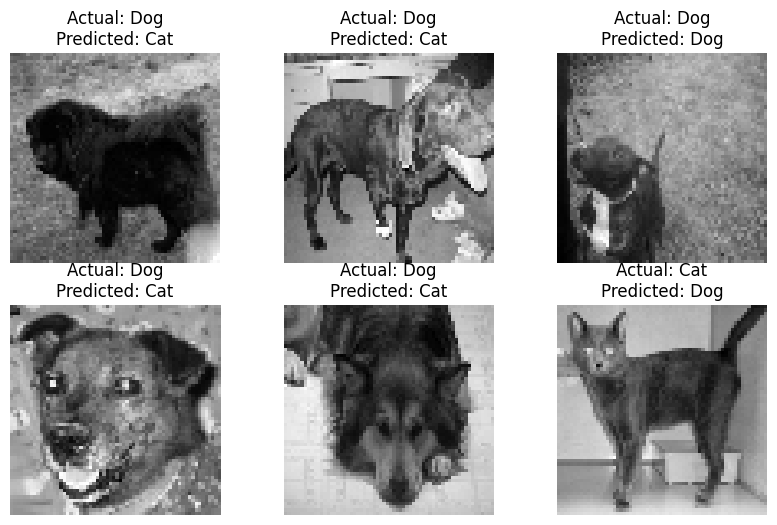

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(6):

    img = X_test[i].reshape(IMG_SIZE, IMG_SIZE)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap='gray')

    actual = "Dog" if y_test[i] == 1 else "Cat"
    predicted = "Dog" if y_pred[i] == 1 else "Cat"

    plt.title("Actual: " + actual + "\nPredicted: " + predicted)
    plt.axis('off')

plt.show()

## Step 11: User Input Image Prediction

Upload a cat or dog image


Saving photo-1478098711619-5ab0b478d6e6.webp to photo-1478098711619-5ab0b478d6e6.webp


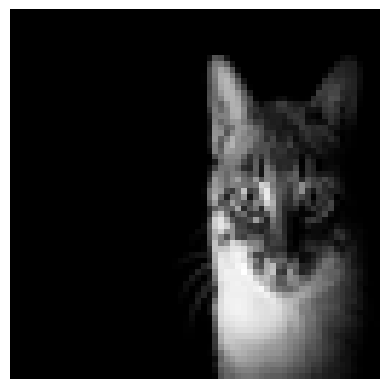

Predicted Image: Cat


In [ ]:
print("Upload a cat or dog image")

uploaded = files.upload()

for filename in uploaded.keys():

    img = Image.open(filename)
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = img.convert('L')

    img_array = np.array(img)
    img_array = img_array.flatten()
    img_array = img_array / 255.0

    img_array = img_array.reshape(1, -1)

    prediction = model.predict(img_array)

    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

    if prediction[0] == 1:
        print("Predicted Image: Dog")
    else:
        print("Predicted Image: Cat")

## End of Project